# SANOS

___
### Summary

SANOS (Smooth strictly Arbitrage-free Non-parametric Option Surfaces) represents call prices as a convex combination of Black-Scholes call kernels anchored at a grid of strikes and variances (observed and extended). The weights, a martingale density, are fit via linear/convex programming to match observed market bid/ask prices; because the combination is convex by construction, the resulting surface is automatically smooth and strictly arbitrage-free, and extends naturally to strikes and expiries beyond those directly quoted.

___
### Main Idea

**For a single expiry**

Call option prices for arbitrary strikes $K$ and some expiry $T_j$ are represented as convex combinations of Black–Scholes call payoffs anchored at strikes $K_j^i$ with (smoothing) variances $V_j$ and weights (martingale density) $q_j$:
$$
\hat{C}(T_j, k) = \sum_{i=1}^{N_j}q_j^i \ \text{Call}(K_j^i, k, V_j)
$$
where $\small j = 0,1,...,M$ corresponds to the market expiries $\small T_0, T_1, ..., T_M$, and $\small i = 1, ..., N_j$ corresponds to the number of strikes (market + extended) at the expiry $\small T_j$

For simplification, $\small \text{Call}(s, k, v)$ is the Black-Scholes call price function for spot $s$, strike $k$ and variance $v$. It will latr be shown that any other martingale call price (such as Heston) can be used.

Black-Scholes kernel have the advantage (e.g. over linear interpolation) to be valid under the risk neutral martingale measure (i.e. no arbitrage), to be smooth and convex.

**No arbitrage constraints**

We say that $q = (q_1, \ldots, q_M)$ with $q_j \in \mathbb{R}^{N_j}$ is a martingale density (*iff* no strike and calendar arbitrage) if it satisfies the linear constraints

*No strike arbitrage*
- Each $q_j$ is a density: $q_j \geq 0, \ q_j' \mathbf{1} = 1$
- Each $q_j$ has unit expectation: $q_j' \hat{K}_j = 1$

*No calendar arbitrage* (Kellerer's theorem)
- The $q$ are in convex order: $c_j \geq c_{j \mid j-1}$

    where $\small c_j^i = q_j'(\hat{K}_j - \hat{K}_j^i)^+$ is the $\small j$-call price for
$\small \hat{K}_j^i$, and $\small c_{j \mid j-1}^i := q_{j-1}'(\hat{K}_{j-1} - \hat{K}_j^i)^+$
is the $\small (j-1)$-call price for $\small \hat{K}_j^i$

**SANOS setup**

In market, we can observe the following data. For each market expiry $T_l$, we have bid $B_l$ and ask $A_l$ prices for OTM calls and puts, for strikes $K_l$.

We first convert these observable bid-ask option prices into pure call prices, that is, we convert the put options to call options by put-call parity, then normalized and de-drift the resulting call options: normalized by the forward price (the strike is now forward-moneyness), remove the drift (pricing under the forward measure), and prices (bid-ask) are normalized by the spot.

Then, we set the surface grid of strike and maturity, by extending the current grid by adding a min and max strike per maturity (for density to be valid, integrate to 1) and adding strike where the difference between 2 consecutives strikes is too large (grid and smoothing purposes).

Recall from above that the SANOS model assigns a single price for each strike at each maturity by $\small \hat{C}(T_j, k) = \sum_{i=1}^{N_j}q_j^i \ \text{Call}(K_j^i, k, V_j)$. 

The variance of the Black-Scholes kernel $V_j$ is increasing in $j$, and requires to be positive. In practice, one can assign the variance for the fixed maturity $T_j$ as the $j^\text{th}$ ATM implied variance, scaled by a factor $\eta$. The paper suggest using $\eta = 0.25$. Thus, the variance of the Black-Scholes kernels is known before model calibration.

**Calibration as a convex optimization problem**

For each market observable expiry $l = 0,1,..., M^{\tiny Market}$ ($\small M^{\tiny Market}$ may differ from $ \small M^{\tiny Model}$), we have ask prices $A_l$, bid prices $B_l$, from which we can deduce the mid prices $M_l$, all assigned with market strikes $K_l$. Note, $A_l$, $B_l$, $M_l$, $K_l$ $\in \mathbb{R}^{N_l^{\tiny Market}}$, for generally $N_l^{\tiny Market} \leq N_l^{\tiny Model}$.

We fit using SANOS $\hat C_l := \text{Call}\big(K_l^{Model}, K_l^{Market}, V_l\big) \cdot q_l \in \mathbb{R}^{N_l^{Market}}$. The market fitting problem is therefore the linear program
$$
\min_q \sum_{l=0}^{M^{\tiny Market}} \frac{1}{\gamma_l} \left[(\hat{C}_l - A_l)^+ + (B_l - \hat{C}_l)^+ + \epsilon |\hat{C}_l - M_l| \right]
$$

subject to the linear constraint:

- Each $q_l$ is a density: $q_l \geq 0, \ q_l' \mathbf{1} = 1$
- Each $q_l$ has unit expectation: $q_l' \hat{K}_l = 1$
- The $q$ are in convex order: $c_l \geq c_{l \mid l-1}$

    where $\small c_l^i = q_l'(\hat{K}_l - \hat{K}_l^i)^+$ is the $\small l$-call price for
$\small \hat{K}_l^i$, and $\small c_{l \mid l-1}^i := q_{l-1}'(\hat{K}_{l-1} - \hat{K}_l^i)^+$
is the $\small (l-1)$-call price for $\small \hat{K}_l^i$

for some penalizing factors $\gamma_l, \epsilon \geq 0$. ($\gamma_l = \frac{1}{A_l - B_l}$ weights more for tight/liquid quotes, $\small \epsilon = 10^{-8}$ adjusts the penalization from deviating from the mid price $M_l$)

Note that we can change the optimization problem. For example, $l^1$ to $l^2$, or using different risk measure, or different weighting policy. Subject to further research and testing.

**Interpolation of the full surface**

For an arbitrary expiry $T \in (T_{j-1}, T_j]$ and strike k, it can be written in term of some increasing weight function $\alpha_j(T) \in [0,1]$.
$$
\begin{aligned}
\hat{C}(T, k) &= \alpha_j(T) \, \sum_{i=1}^{N_j} q_j^i \, \text{Call}(K_j^i, k, V(T)) \\
&\quad + (1 - \alpha_j(T)) \, \sum_{i=1}^{N_{j-1}} q_{j-1}^i \, \text{Call}(K_{j-1}^i, k, V(T))
\end{aligned}
$$
for some shared (smoothing) variance $\small V(T) := \alpha_j(T) V_j + (1 - \alpha_j(T)) V_{j-1}$

A simple choice for the time-interpolation function $\alpha_j(T)$ is the linear interpolation
$$
\alpha_j(T) := \frac{T - T_{j-1}}{T_j - T_{j-1}}, \ \ \  \small \text{for some } T \in (T_{j-1}, T_j]
$$

The authors recommand in practice to use $C^1$ monotone spline

**Notes**

In the above, $\small N_0=1, q_0^1 := 1, K_1^1 := 1$

___
### 1. Option Data (single expiry)

In [13]:
import pandas as pd
from datetime import date
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

In [14]:
option_data = pd.read_csv("../Data/TSLA_OptionData.csv")
# option_data = pd.read_csv("https://raw.githubusercontent.com/victorlabrecque-ops/Project_summer/main/Data/TSLA_OptionData.csv")
spot = 429.52
current_date = date(2025, 11, 7)
expiry = date(2025, 12, 19)
ttm = (expiry - current_date).days / 365
rf = 0.038

___
### 2. Convert Data

Put-call parity states that:
$$
C_t(K, T) = P_t(K, T) + S_t - K \ e^{-r(T-t)}
$$

In [15]:
discount = np.exp(-rf * ttm)

puts = option_data[option_data['Type'] == 'P'].copy()
puts['Bid'] = puts['Bid'] + spot - puts['Strike'] * discount
puts['Ask'] = puts['Ask'] + spot - puts['Strike'] * discount
puts['Type'] = 'C'
puts['Mid-Price'] = (puts['Ask'] + puts['Bid']) / 2
puts['Spread'] = puts['Ask'] - puts['Bid']

calls = option_data[option_data['Type'] == 'C'].copy()

options = pd.concat([puts, calls], ignore_index=True)

**Normalization**: convert price into pure price.

For a non-dividend paying stock, the forward price is simply $F = S \ e^{rT}$

In [16]:
forward = spot * np.exp(rf * ttm)

k = options['Strike'].to_numpy() / forward
bid = options['Bid'].to_numpy() / spot
ask = options['Ask'].to_numpy() / spot
mid = 0.5 * (bid + ask)

#check
assert np.all(np.diff(k) > 0), "strikes must be strictly increasing"
assert np.all(bid < ask), "bid must be below ask"

### 3. Black-Scholes Kernel

In [17]:
def bs_call_price(m, vf):
    """
    Normalized (spot=1) BS call price
    m = strike/spot ratio
    vf = vol*sqrt(T)
    """
    m = np.asarray(m, dtype=float)
    vf = np.asarray(vf, dtype=float)
    d1 = -np.log(m) / vf + 0.5 * vf
    d2 = d1 - vf
    return norm.cdf(d1) - m * norm.cdf(d2)

def kernel_matrix(strikes, xk, xv, T):
    """
    kernel_matrix[j, i] = price of a call struck at strikes[j] 
    if the underlying's spot were xk[i] with vol xv[i]
    This calculate all kernel values at once
    """
    m = strikes[:, None] / xk[None, :]
    vf = xv[None, :] * np.sqrt(T)
    return bs_call_price(m, vf) * xk[None, :]

### 4. Extended Grid

In [18]:
# extended grid: market strikes plus extrapolation tails 
# (no interior densification needed), quotes are already ok placed

k_min, k_max = 0.5, 1.8
xk = np.concatenate(([k_min], k, [k_max]))
N = len(xk)

# kernel bandwidth: vol_fac * ATM vol, flat across the whole grid
atm_mid = np.interp(1.0, k, mid)  #interpolate mid-price at ATM strike
atm_vol = brentq(lambda v: bs_call_price(1.0, v * np.sqrt(ttm)) - atm_mid, 1e-4, 5.0) #ATM implied vol

vol_fac = 0.5   #smoothing factor (0 -> linear interpolation, 1 -> full smoothing)
xv = np.full(N, vol_fac * atm_vol)


### 5. Optimization Problem

In [19]:
import cvxpy as cp

Phi = kernel_matrix(k, xk, xv, ttm)   # (M, N): model price at each market strike, as a function of the density

q = cp.Variable(N)  #variable to optimize (N-size vector)
fitted = Phi @ q    #matrix multiplication for fitted objective
                    #size (M,1) vector of fitted prices at market strikes
                    #each element of the vectors has N terms (extended # strikes)

weight = np.minimum(1.0 / (ask - bid), 100.0)  #tight bid-ask = big weight
weight /= weight.sum()    #normalize weights to sum to 1

constraints = [
    q >= 0,          # valid density
    cp.sum(q) == 1,  # valid probability
    q @ xk == 1,     # martingale: E[K] = forward = 1
]
mid_penalty_weight = 1e-8
mid_err = cp.multiply(weight, cp.abs(fitted - mid))   # penalty for pricing away from the mid
ask_err = cp.multiply(weight, cp.pos(fitted - ask))   # penalty for pricing above the ask
bid_err = cp.multiply(weight, cp.pos(bid - fitted))   # penalty for pricing below the bid

objective = mid_penalty_weight * cp.sum(mid_err) + cp.sum(ask_err) + cp.sum(bid_err)   #objective function

prob = cp.Problem(cp.Minimize(objective), constraints)   #to solve
prob.solve(solver="CLARABEL")     #solver1
if prob.status != "optimal":
    prob.solve(solver="SCS", eps_abs=1e-8)  #solver2 if 1 fails

print(prob.status)
if prob.status not in ("optimal", "optimal_inaccurate"):
    raise RuntimeError(f"Solver failed: {prob.status}")

density = np.maximum(q.value, 0.0)   #max just to ensure positive and not -1e-12



optimal


### 6. Get surface from optimized weights

In [20]:
def sanos_price(strikes):    #SANOS smooth smile
    strikes = np.atleast_1d(strikes).astype(float)
    return kernel_matrix(strikes, xk, xv, ttm) @ density

def implied_vol(strikes, prices):   #solve implied vol from price and strike
    strikes = np.atleast_1d(strikes).astype(float)
    prices = np.atleast_1d(prices).astype(float)
    return np.array([
        brentq(lambda v: bs_call_price(s, v * np.sqrt(ttm)) - c, 1e-4, 5.0)
        for s, c in zip(strikes, prices)
    ])


# Get surfaces
fitted_prices = sanos_price(k)     #get price surface grid
fitted_iv = implied_vol(k, fitted_prices)   # get vol surface grid
bid_iv = implied_vol(k, bid)     # get bid implied vol surface grid 
ask_iv = implied_vol(k, ask)     # get ask implied vol surface grid 


### 7. Density

**Model Analytical Density**

Breeden and Litzenberger (1978) showed that the state-price density of an asset can be recovered directly from a cross-section of option prices. By taking the second derivative of option prices with respect to strike, it is possible to extract the market-implied probability distribution of the underlying price at a specific expiry

SANOS is built on a linear combination of Black-Scholes call price kernels. The density is defined as $q(K) = \frac{\partial^2{\hat{C}}}{\partial{K}^2}$ where from SANOS, for an expiry $T_j$
$$
\hat{C}(k) = \sum_{i=0}^{N}q^i \ \text{BSCall}(K^i, k, v)
$$

For a single (normalized) Black-Scholes call price
$$
\text{BSCall}(s, k, v) = S \ \Phi(d_+) - K \ \Phi(d_-)
$$

where $\Phi(\cdot)$ is the standard normal CDF and $d_\pm = \frac{\ln\frac{s}{k} \pm \frac{v}{2}}{\sqrt{v}}$

we have
$$\frac{\partial \ \text{BSCall}}{\partial k} = -\Phi(d_-)$$
and then
$$\frac{\partial^2 \ \text{BSCall}}{\partial k^2} = \frac{1}{k\sqrt{v}} \ \phi(d_-)$$
where $\phi(x)$ is the pdf of standard normal rv.

So,
$$\frac{\partial^2 \ \text{BSCall}}{\partial k^2} = \frac{1}{k\sqrt{v}\sqrt{2\pi}}\exp\left(-\frac{(\ln{\frac{k}{s}} + \frac{v}{2})^2}{2v}\right)$$

Which is the lognormal density of a rv $k$ with mean $s$: $\ln{k} \sim \mathcal{N}(\ln{s} - \frac{v}{2}, v)$

Now, since $\hat{C}(k)$ is linear in strikes $K^i$, the differentiation passes through the sum leading to the density being the weighted sum of lognormal densities.
$$
q(k) = \frac{\partial^2{\hat{C}}}{\partial{k}^2} = \sum_{i=0}^{N}q^i \ \frac{\partial^2 \ \text{BSCall}(K^i, k, v)}{\partial k^2}
$$
Note that $q(k)$ is a valid pdf function since $\sum_{i=0}^N q^i = 1 \implies \int_k q(k)dk = 1$ for whatever $v \geq 0$.


**Raw market-implied density**

The raw market-implied density is the finite-difference second derivative of interpolated market mids

1. Linear interpolation of the market mid price $M_i$ between market strikes
$$
\bar M(K) = M_i + \frac{M_{i+1}-M_i}{k_{i+1}-k_i}(K-k_i), \qquad K\in[k_i,k_{i+1}]
$$
2. First finite difference: Approximate $\frac{\partial M}{\partial K}$, the derivative at each grid point with the central difference formula:
$$
\bar M'(x_i) \approx \frac{\bar M(x_{i+1}) - \bar M(x_{i-1})}{x_{i+1}-x_{i-1}}
$$
3. Second finite difference: Approximate $\frac{\partial^2 M}{\partial K^2}$:
$$
\bar M''(x_i) \approx \frac{\bar M'(x_{i+1}) - \bar M'(x_{i-1})}{x_{i+1}-x_{i-1}}
$$

Differencing at step functions (1st derivative of linear interpolation) gives zero almost everywhere, with spikes at market strikes.

This is considered raw density since it does not use SANOS, thus does not inforce non-arbitrage.

Arbitrage occurs when the raw density is negative. Note that this does not imply that the market has an arbitrage opportunity, since we are using mid price (bid-ask can cancel this arbitrage), or since not all prices are quoted at the same time.

In [21]:
def sanos_density(strikes):
    """
    Analytic mixture-of-lognormals density: 
    q(k) = Σ_i density[i] · LogNormal-PDF(k; mean=xk[i], stdev=xv[i]√T)
    """
    strikes = np.atleast_1d(strikes).astype(float)
    vf = xv * np.sqrt(ttm)                                    # (N,) total stdev per kernel
    log_m = np.log(strikes[:, None] / xk[None, :])             # (M, N)
    pdf = np.exp(-0.5 * (log_m + 0.5 * vf[None, :]**2)**2 / vf[None, :]**2) \
          / (strikes[:, None] * vf[None, :] * np.sqrt(2 * np.pi))
    return pdf @ density


In [22]:
"""
Raw market-implied density
"""
test_k = np.linspace(xk[0], xk[-1], 400)
test_prices = sanos_price(test_k)
test_iv = implied_vol(test_k, test_prices)
test_density = sanos_density(test_k)

# raw market-implied density: finite-difference second derivative of interpolated market mids
market_test_mid = np.interp(test_k, k, mid)
dM = np.gradient(market_test_mid, test_k, edge_order=2)
market_density = np.gradient(dM, test_k, edge_order=2)

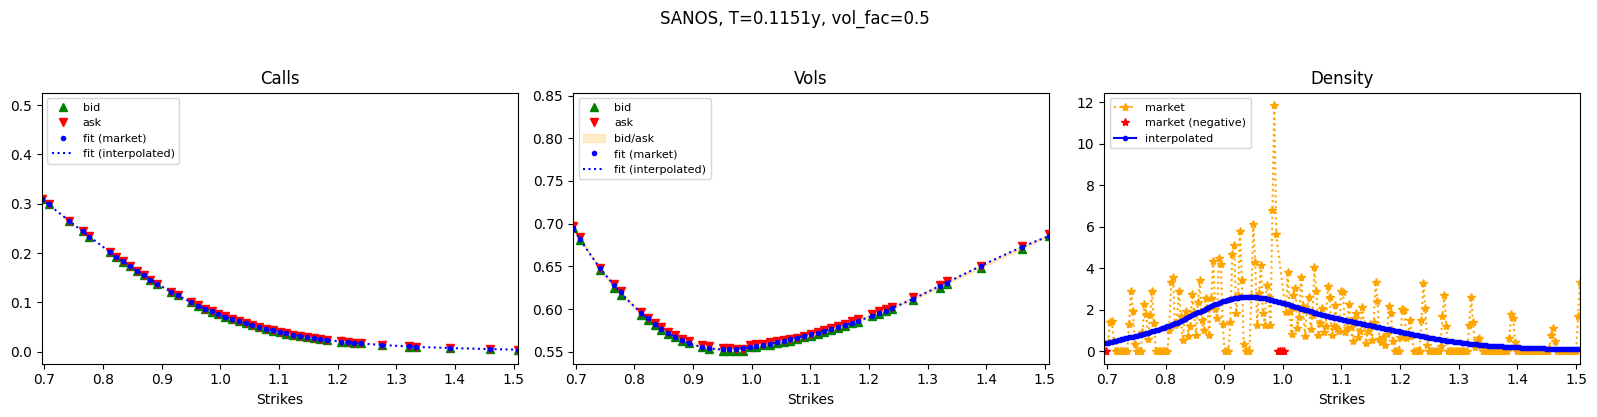

In [23]:
"""
Generate Graphs : 
    fitted pure call prices,
    fitted implied vols, 
    fitted density
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Calls
axC = axes[0]
axC.plot(k, bid, "^", color="green", label="bid")
axC.plot(k, ask, "v", color="red", label="ask")
axC.plot(k, fitted_prices, ".", color="blue", label="fit (market)")
axC.plot(test_k, test_prices, ":", color="blue", label="fit (interpolated)")
axC.set_title("Calls"); axC.set_xlabel("Strikes"); axC.set_xlim(k[0], k[-1])
axC.legend(loc="upper left", fontsize=8)

# Vols
axV = axes[1]
axV.plot(k, bid_iv, "^", color="green", label="bid")
axV.plot(k, ask_iv, "v", color="red", label="ask")
axV.fill_between(k, bid_iv, ask_iv, color="orange", alpha=0.2, label="bid/ask")
axV.plot(k, fitted_iv, ".", color="blue", label="fit (market)")
axV.plot(test_k, test_iv, ":", color="blue", label="fit (interpolated)")
axV.set_title("Vols"); axV.set_xlabel("Strikes"); axV.set_xlim(k[0], k[-1])
axV.legend(loc="upper left", fontsize=8)

# Density
axD = axes[2]
epsd = -1e-6
pos = market_density >= epsd
axD.plot(test_k[pos], market_density[pos], "*:", color="orange", label="market")
if np.any(~pos):
    axD.plot(test_k[~pos], np.zeros_like(market_density[~pos]), "*", color="red", label="market (negative)")
axD.plot(test_k, test_density, ".-", color="blue", label="interpolated")
axD.set_title("Density"); axD.set_xlabel("Strikes"); axD.set_xlim(k[0], k[-1])
axD.legend(loc="upper left", fontsize=8)

fig.suptitle(f"SANOS, T={ttm:.4f}y, vol_fac={vol_fac}", y=1.03)
plt.tight_layout()
plt.show()

___
### TO DO next

**What to check**
- smoothing parameter ($\eta = \text{volfac}^2$)
- weight of penalized term for deviation from mid price
- No interieur extended grid (since current is spaced ok)

**TO DO**
- Calendar term for full surface
- American vs European options

**Paper to read**
- Lognormal mixture dynamics
- Breeden-Litzenberger: ∂²C/∂K² (discrete density)
- De-Americanisation of options
- DYSANOS